# Explanation Model
### Target: `avg_days_per_household` — measures how well MGNREGA delivers its 100-day guarantee
### Key Note: AP was reorganized from 13 to 26 districts in April 2022.
### Zero-value districts (new districts before 2022) are excluded from year-wise averages.
### 2025 data excluded — financial year was incomplete at time of data collection (March 2026).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

df_full = pd.read_csv('D:/sem4/DWDM/AP-MGNREGA-DATA-ANALYSIS/datasets/clean_mgnrega_dataset.csv')

# Clean dataset — exclude zero-value district-year rows
# These are new districts created in AP reorganization 2022
# that did not exist as separate units before 2022
df = df_full[df_full['avg_days_per_household'] > 0].copy()

print(f'Full dataset (after removing 2025): {df_full.shape}')
print(f'Analysis dataset (zeros excluded) : {df.shape}')
print(f'Years covered: {sorted(df["year"].unique())}')
print(f'Districts per year:')
print(df.groupby('year')['district'].count().to_string())

Full dataset (after removing 2025): (262, 19)
Analysis dataset (zeros excluded) : (182, 19)
Years covered: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Districts per year:
year
2016    13
2017    13
2018    13
2019    13
2020    13
2021    13
2022    26
2023    26
2024    26
2025    26


## Step 1: Distribution of `avg_days_per_household`

In [2]:
target = 'avg_days_per_household'

print('=== Distribution Summary ===')
print(df[target].describe().round(2))
print()
print(f'Values above 100 days (exceeds guarantee) : {(df[target] > 100).sum()}')
print(f'Values below 30 days (severely low)       : {(df[target] < 30).sum()}')
print(f'Values between 30-100 (normal range)      : {((df[target] >= 30) & (df[target] <= 100)).sum()}')
print(f'Overall AP mean                           : {df[target].mean():.2f} days')
print(f'Gap from 100-day guarantee                : {100 - df[target].mean():.2f} days')

=== Distribution Summary ===
count    182.00
mean      50.99
std       10.35
min       25.51
25%       43.36
50%       51.04
75%       58.10
max       74.86
Name: avg_days_per_household, dtype: float64

Values above 100 days (exceeds guarantee) : 0
Values below 30 days (severely low)       : 1
Values between 30-100 (normal range)      : 181
Overall AP mean                           : 50.99 days
Gap from 100-day guarantee                : 49.01 days


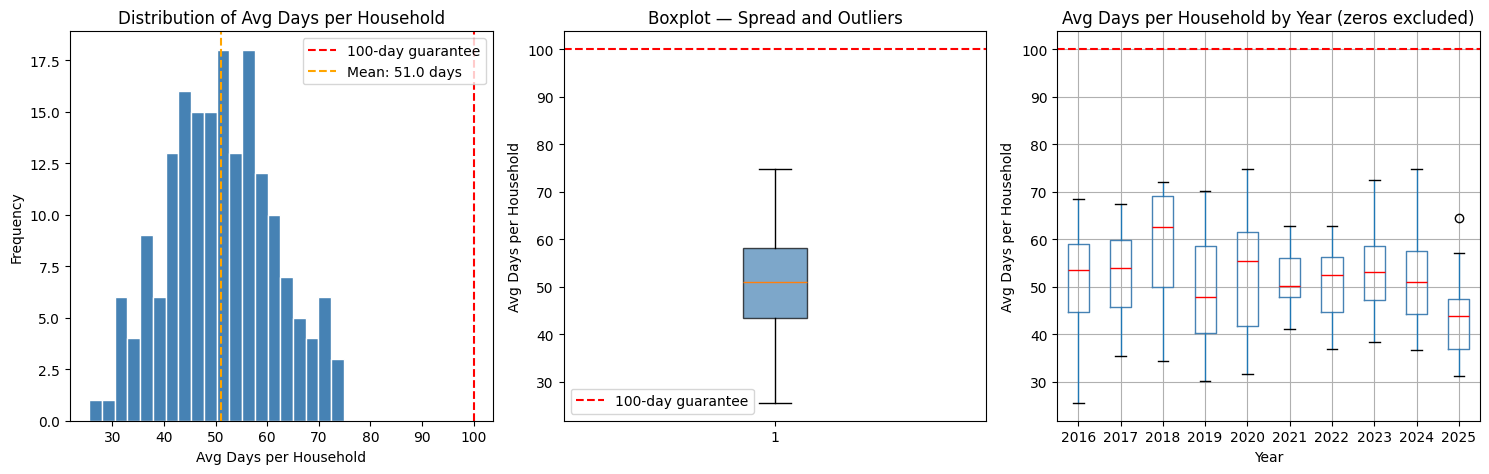

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
axes[0].hist(df[target], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(100, color='red', linestyle='--', linewidth=1.5, label='100-day guarantee')
axes[0].axvline(df[target].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {df[target].mean():.1f} days')
axes[0].set_xlabel('Avg Days per Household')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Avg Days per Household')
axes[0].legend()

# Boxplot
axes[1].boxplot(df[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].axhline(100, color='red', linestyle='--', linewidth=1.5, label='100-day guarantee')
axes[1].set_ylabel('Avg Days per Household')
axes[1].set_title('Boxplot — Spread and Outliers')
axes[1].legend()

# Year-wise boxplot
df.boxplot(column=target, by='year', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
axes[2].axhline(100, color='red', linestyle='--', linewidth=1.5, label='100-day guarantee')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg Days per Household')
axes[2].set_title('Avg Days per Household by Year (zeros excluded)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Step 2: Year-wise Trend — Is Delivery Improving?
### 2016-2021: based on original 13 districts only
### 2022-2024: based on all 26 districts after AP reorganization

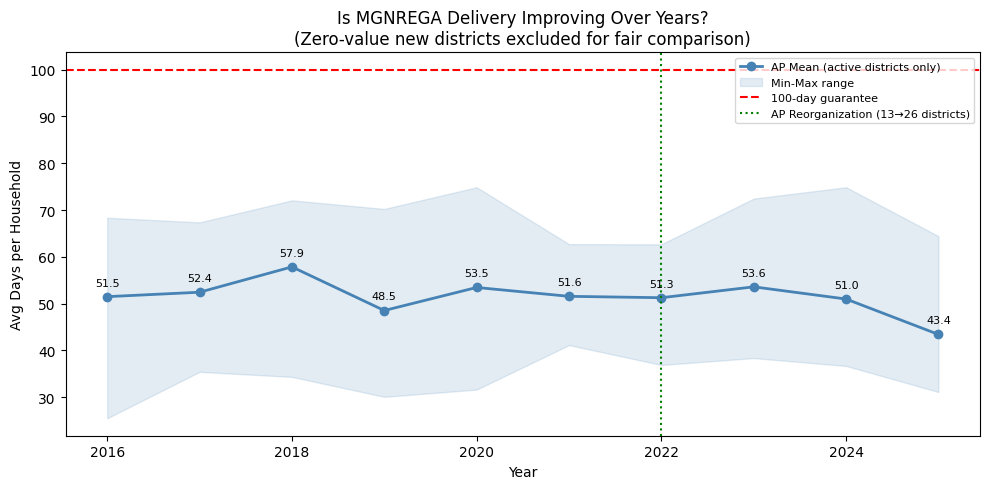

 year  mean_days  min_days  max_days  district_count
 2016  51.491538     25.51     68.35              13
 2017  52.438462     35.43     67.36              13
 2018  57.852308     34.35     72.06              13
 2019  48.530000     30.09     70.23              13
 2020  53.454615     31.64     74.86              13
 2021  51.561538     41.14     62.71              13
 2022  51.265385     36.90     62.67              26
 2023  53.590000     38.37     72.44              26
 2024  50.985000     36.69     74.86              26
 2025  43.422308     31.13     64.42              26


In [4]:
yearly = df.groupby('year').agg(
    mean_days=('avg_days_per_household', 'mean'),
    min_days=('avg_days_per_household', 'min'),
    max_days=('avg_days_per_household', 'max'),
    district_count=('district', 'count')
).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['mean_days'], marker='o', color='steelblue',
         linewidth=2, label='AP Mean (active districts only)')
plt.fill_between(yearly['year'], yearly['min_days'], yearly['max_days'],
                 alpha=0.15, color='steelblue', label='Min-Max range')
plt.axhline(100, color='red', linestyle='--', linewidth=1.5, label='100-day guarantee')

# Mark the reorganization year
plt.axvline(2022, color='green', linestyle=':', linewidth=1.5, label='AP Reorganization (13→26 districts)')

# Annotate mean values
for _, row in yearly.iterrows():
    plt.annotate(f"{row['mean_days']:.1f}",
                 (row['year'], row['mean_days']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.xlabel('Year')
plt.ylabel('Avg Days per Household')
plt.title('Is MGNREGA Delivery Improving Over Years?\n(Zero-value new districts excluded for fair comparison)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(yearly.to_string(index=False))

## Step 3: Correlation of Features with `avg_days_per_household`
### What factors are associated with better/worse delivery of the guarantee?

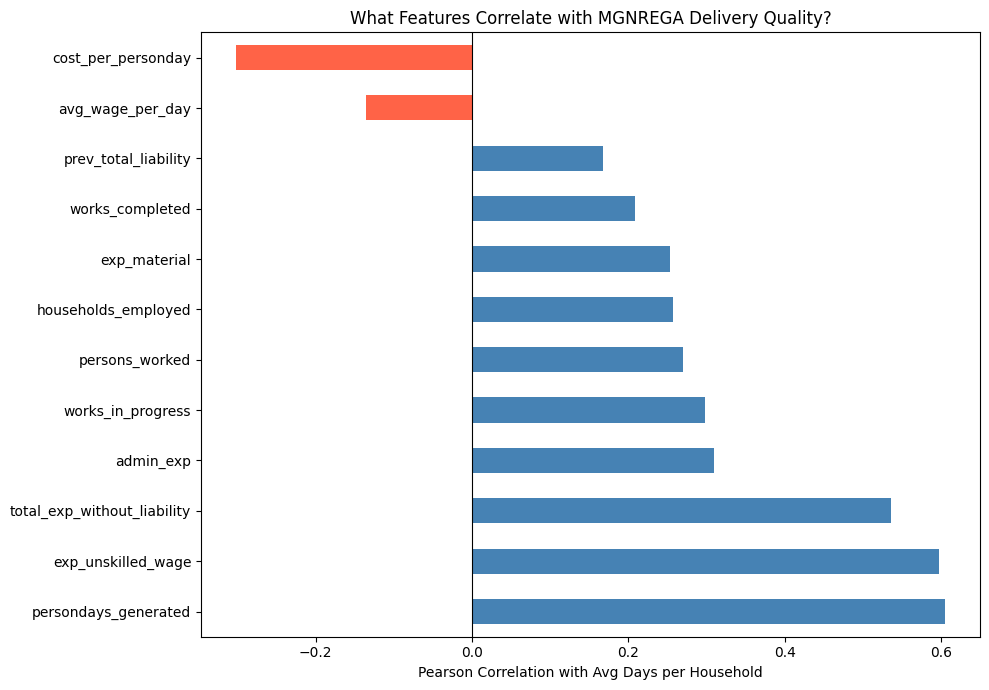

persondays_generated           0.6046
exp_unskilled_wage             0.5969
total_exp_without_liability    0.5359
admin_exp                      0.3094
works_in_progress              0.2979
persons_worked                 0.2695
households_employed            0.2567
exp_material                   0.2535
works_completed                0.2084
prev_total_liability           0.1677
avg_wage_per_day              -0.1358
cost_per_personday            -0.3015
Name: avg_days_per_household, dtype: float64


In [5]:
numeric_cols = [
    'exp_unskilled_wage',
    'exp_material',
    'admin_exp',
    'total_exp_without_liability',
    'households_employed',
    'persons_worked',
    'persondays_generated',
    'avg_wage_per_day',
    'works_completed',
    'works_in_progress',
    'cost_per_personday',
    'prev_total_liability',
    'avg_days_per_household'
]

corr_with_target = df[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with Avg Days per Household')
plt.title('What Features Correlate with MGNREGA Delivery Quality?')
plt.tight_layout()
plt.show()

print(corr_with_target.round(4))

## Step 4: Full Correlation Heatmap
### Spots multicollinearity — features that are saying the same thing

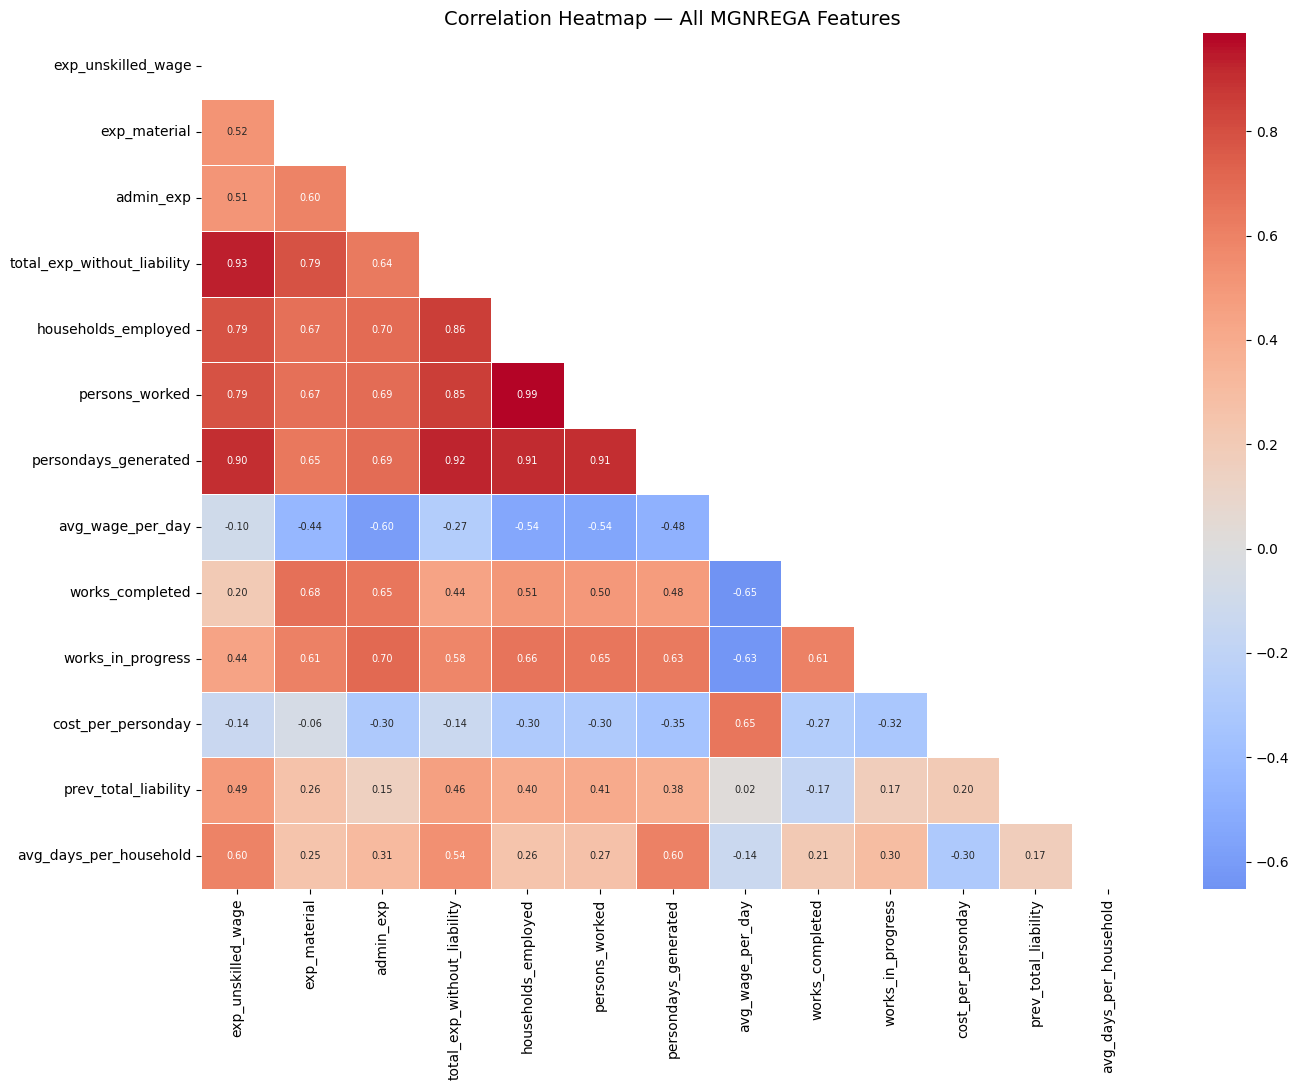

In [6]:
plt.figure(figsize=(14, 11))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Heatmap — All MGNREGA Features', fontsize=14)
plt.tight_layout()
plt.show()

## Step 5: Standardized Linear Regression Coefficients
### Direction + magnitude of each driver on avg days per household
### Positive = increases delivery days, Negative = reduces delivery days

Linear Regression R²: 0.4363

             feature  coefficient
  exp_unskilled_wage     6.470379
     works_completed     2.793510
    avg_wage_per_day     1.967797
   works_in_progress     0.480046
prev_total_liability     0.082899
           admin_exp    -0.991929
        exp_material    -1.646931
  cost_per_personday    -2.966128


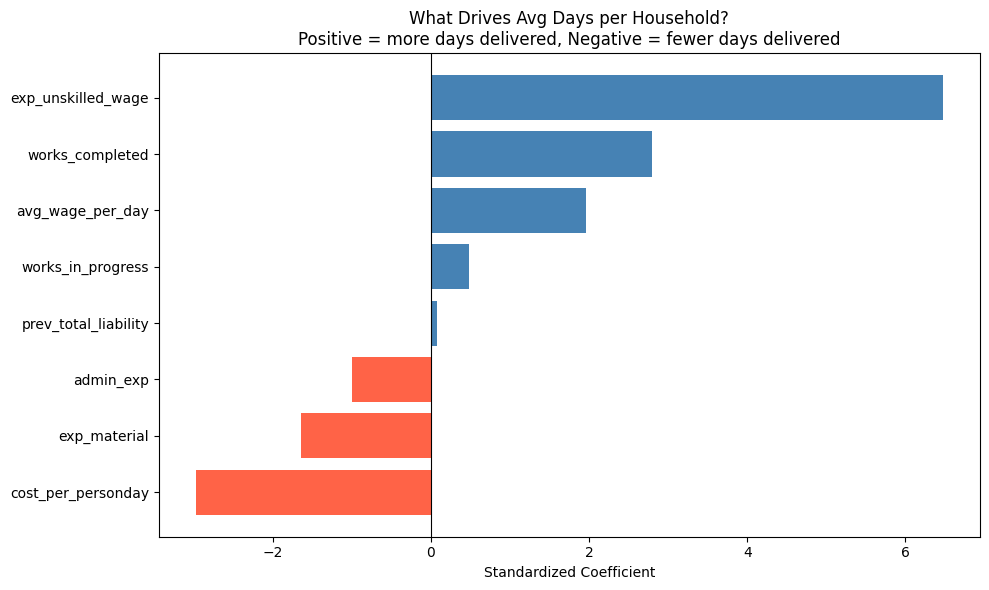

In [7]:
explanation_features = [
    'exp_unskilled_wage',
    'exp_material',
    'admin_exp',
    'works_completed',
    'works_in_progress',
    'avg_wage_per_day',
    'cost_per_personday',
    'prev_total_liability'
]

X_exp = df[explanation_features].dropna()
y_exp = df.loc[X_exp.index, target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_exp)

lr = LinearRegression()
lr.fit(X_scaled, y_exp)

coef_df = pd.DataFrame({
    'feature': explanation_features,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)

r2 = r2_score(y_exp, lr.predict(X_scaled))
print(f'Linear Regression R²: {r2:.4f}')
print()
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in coef_df['coefficient']]
plt.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized Coefficient')
plt.title('What Drives Avg Days per Household?\nPositive = more days delivered, Negative = fewer days delivered')
plt.tight_layout()
plt.show()

## Step 6: Budget vs Employment Trend
### Is rising budget translating to rising employment?

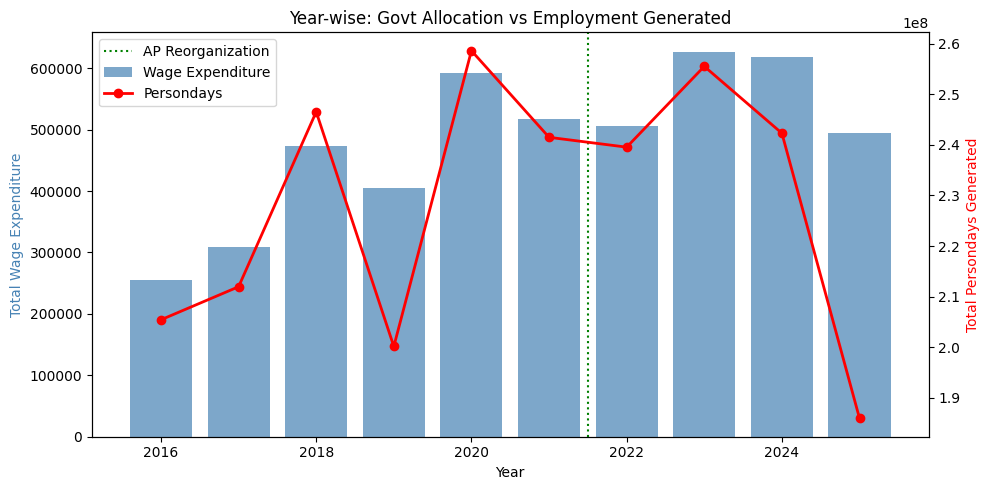

Year-wise efficiency (persondays per rupee):
 year  total_wage_exp  total_persondays  persondays_per_rupee
 2016       255826.01         205441159            803.050319
 2017       308430.62         211967376            687.244918
 2018       473888.18         246508258            520.182331
 2019       405013.70         200172975            494.237541
 2020       592688.28         258584109            436.290235
 2021       517178.87         241478532            466.914922
 2022       505876.75         239535800            473.506244
 2023       627101.22         255491901            407.417324
 2024       617926.38         242282072            392.088896
 2025       494417.25         185970663            376.141130


In [8]:
# Use full dataset (all districts) for expenditure since budget was allocated to all
budget_yearly = df_full.groupby('year').agg(
    total_wage_exp=('exp_unskilled_wage', 'sum'),
    total_persondays=('persondays_generated', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(budget_yearly['year'], budget_yearly['total_wage_exp'],
        color='steelblue', alpha=0.7, label='Wage Expenditure')
ax2.plot(budget_yearly['year'], budget_yearly['total_persondays'],
         color='red', marker='o', linewidth=2, label='Persondays')

ax1.axvline(2021.5, color='green', linestyle=':', linewidth=1.5, label='AP Reorganization')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Wage Expenditure', color='steelblue')
ax2.set_ylabel('Total Persondays Generated', color='red')
plt.title('Year-wise: Govt Allocation vs Employment Generated')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

# Efficiency ratio
budget_yearly['persondays_per_rupee'] = budget_yearly['total_persondays'] / budget_yearly['total_wage_exp']
print('Year-wise efficiency (persondays per rupee):')
print(budget_yearly[['year','total_wage_exp','total_persondays','persondays_per_rupee']].to_string(index=False))


## Step 7: District-wise Average Days per Household

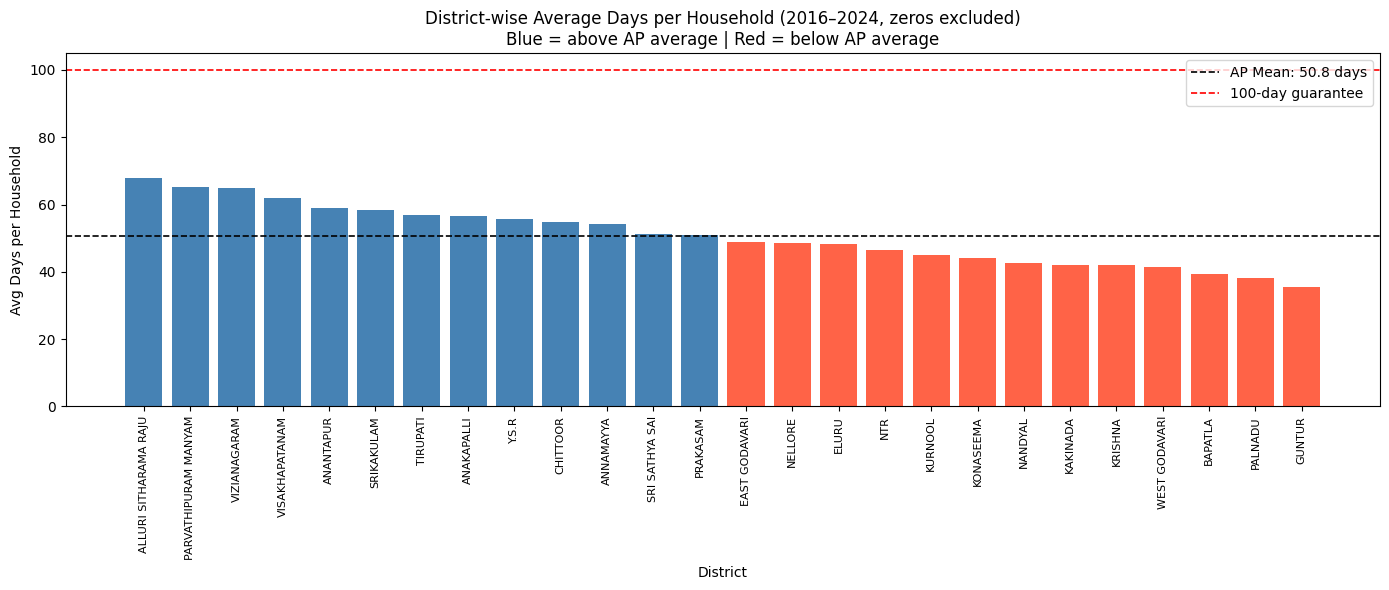

Best district  : ALLURI SITHARAMA RAJU (68.0 days)
Worst district : GUNTUR (35.3 days)

Full district ranking:
district
ALLURI SITHARAMA RAJU    68.00
PARVATHIPURAM MANYAM     65.08
VIZIANAGARAM             64.83
VISAKHAPATANAM           61.97
ANANTAPUR                58.95
SRIKAKULAM               58.33
TIRUPATI                 56.78
ANAKAPALLI               56.47
Y.S.R                    55.80
CHITTOOR                 54.72
ANNAMAYYA                54.06
SRI SATHYA SAI           51.34
PRAKASAM                 51.00
EAST GODAVARI            48.90
NELLORE                  48.51
ELURU                    48.40
NTR                      46.54
KURNOOL                  44.85
KONASEEMA                44.08
NANDYAL                  42.65
KAKINADA                 42.10
KRISHNA                  42.05
WEST GODAVARI            41.50
BAPATLA                  39.42
PALNADU                  38.24
GUNTUR                   35.33


In [9]:

district_avg = df.groupby('district')['avg_days_per_household'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
colors = ['steelblue' if v >= district_avg.mean() else 'tomato' for v in district_avg]
plt.bar(district_avg.index, district_avg.values, color=colors)
plt.axhline(district_avg.mean(), color='black', linestyle='--', linewidth=1.2, label=f'AP Mean: {district_avg.mean():.1f} days')
plt.axhline(100, color='red', linestyle='--', linewidth=1.2, label='100-day guarantee')
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('District')
plt.ylabel('Avg Days per Household')
plt.title('District-wise Average Days per Household (2016–2024, zeros excluded)\nBlue = above AP average | Red = below AP average')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best district  : {district_avg.idxmax()} ({district_avg.max():.1f} days)")
print(f"Worst district : {district_avg.idxmin()} ({district_avg.min():.1f} days)")
print(f"\nFull district ranking:")
print(district_avg.round(2).to_string())

## Step 8: Summary of Key Findings

In [10]:
print('=' * 65)
print('EXPLANATION MODEL — KEY FINDINGS')
print('=' * 65)
print()
print('--- DATASET ---')
print(f'  Years analyzed          : 2016-2024 (2025 excluded — incomplete)')
print(f'  Districts 2016-2021     : 13 (original AP districts)')
print(f'  Districts 2022-2024     : 26 (after AP reorganization)')
print()
print('--- DELIVERY AGAINST 100-DAY GUARANTEE ---')
print(f'  Overall AP mean         : {df[target].mean():.2f} days')
print(f'  Gap from guarantee      : {100 - df[target].mean():.2f} days short')
print(f'  Best year               : {yearly.loc[yearly["mean_days"].idxmax(), "year"]} ({yearly["mean_days"].max():.1f} days)')
print(f'  Worst year              : {yearly.loc[yearly["mean_days"].idxmin(), "year"]} ({yearly["mean_days"].min():.1f} days)')
print()
print('--- DISTRICT PERFORMANCE ---')
print(f'  Best district           : {district_avg.idxmax()} ({district_avg.max():.1f} days)')
print(f'  Worst district          : {district_avg.idxmin()} ({district_avg.min():.1f} days)')
print(f'  Above AP average        : {(district_avg >= district_avg.mean()).sum()} districts')
print(f'  Below AP average        : {(district_avg < district_avg.mean()).sum()} districts')
print()
print('--- TOP DRIVERS (Correlation with avg days) ---')
print('  Positive drivers:')
for feat, val in corr_with_target[corr_with_target > 0].head(3).items():
    print(f'    {feat:<35} r = {val:.4f}')
print('  Negative drivers:')
for feat, val in corr_with_target[corr_with_target < 0].head(3).items():
    print(f'    {feat:<35} r = {val:.4f}')
print('=' * 65)

EXPLANATION MODEL — KEY FINDINGS

--- DATASET ---
  Years analyzed          : 2016-2024 (2025 excluded — incomplete)
  Districts 2016-2021     : 13 (original AP districts)
  Districts 2022-2024     : 26 (after AP reorganization)

--- DELIVERY AGAINST 100-DAY GUARANTEE ---
  Overall AP mean         : 50.99 days
  Gap from guarantee      : 49.01 days short
  Best year               : 2018 (57.9 days)
  Worst year              : 2025 (43.4 days)

--- DISTRICT PERFORMANCE ---
  Best district           : ALLURI SITHARAMA RAJU (68.0 days)
  Worst district          : GUNTUR (35.3 days)
  Above AP average        : 13 districts
  Below AP average        : 13 districts

--- TOP DRIVERS (Correlation with avg days) ---
  Positive drivers:
    persondays_generated                r = 0.6046
    exp_unskilled_wage                  r = 0.5969
    total_exp_without_liability         r = 0.5359
  Negative drivers:
    avg_wage_per_day                    r = -0.1358
    cost_per_personday                